In [1]:
# ============================================
# FYP MODEL IMPROVEMENT EXPERIMENTS (CORRECTED)
# ============================================
# All models are evaluated under identical conditions:
# - 3-Fold TimeSeriesSplit Cross-Validation
# - Same training data
# - Same test set evaluation
# - Same metrics reported

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, 
    f1_score, classification_report, confusion_matrix
)
from sklearn.feature_selection import SelectFromModel
import joblib
import warnings
warnings.filterwarnings('ignore')

FYP MODEL IMPROVEMENT EXPERIMENTS (CORRECTED)
All experiments use identical evaluation conditions

[Step 1] Loading data and setting up evaluation framework...
✓ Data loaded:
  Training: (654, 29)
  Validation: (110, 29)
  Test: (220, 29)
  Features: 29
  Cross-validation: 3-Fold TimeSeriesSplit

[Step 2] Defining standardized evaluation function...
✓ Standardized evaluation function defined

EXPERIMENT 0: BASELINE RANDOM FOREST

Model Configuration:
  n_estimators: 100
  max_depth: 10
  min_samples_leaf: 5
  class_weight: balanced

  Cross-Validation Results (3-Fold TimeSeriesSplit):
    Accuracy:  0.6237 ± 0.0502
    Precision: 0.3639 ± 0.0669
    Recall:    0.3317 ± 0.1095
    F1 Score:  0.3436 ± 0.0906
    ROC-AUC:   0.6046 ± 0.0785

  Test Set Results:
    Accuracy:  0.6318
    Precision: 0.3488
    Recall:    0.2206
    F1 Score:  0.2703
    ROC-AUC:   0.5302

  Generalization Gap (CV - Test ROC-AUC): 0.0744
    ⚠️ Warning: Significant overfitting detected

EXPERIMENT 1: IMPROVED

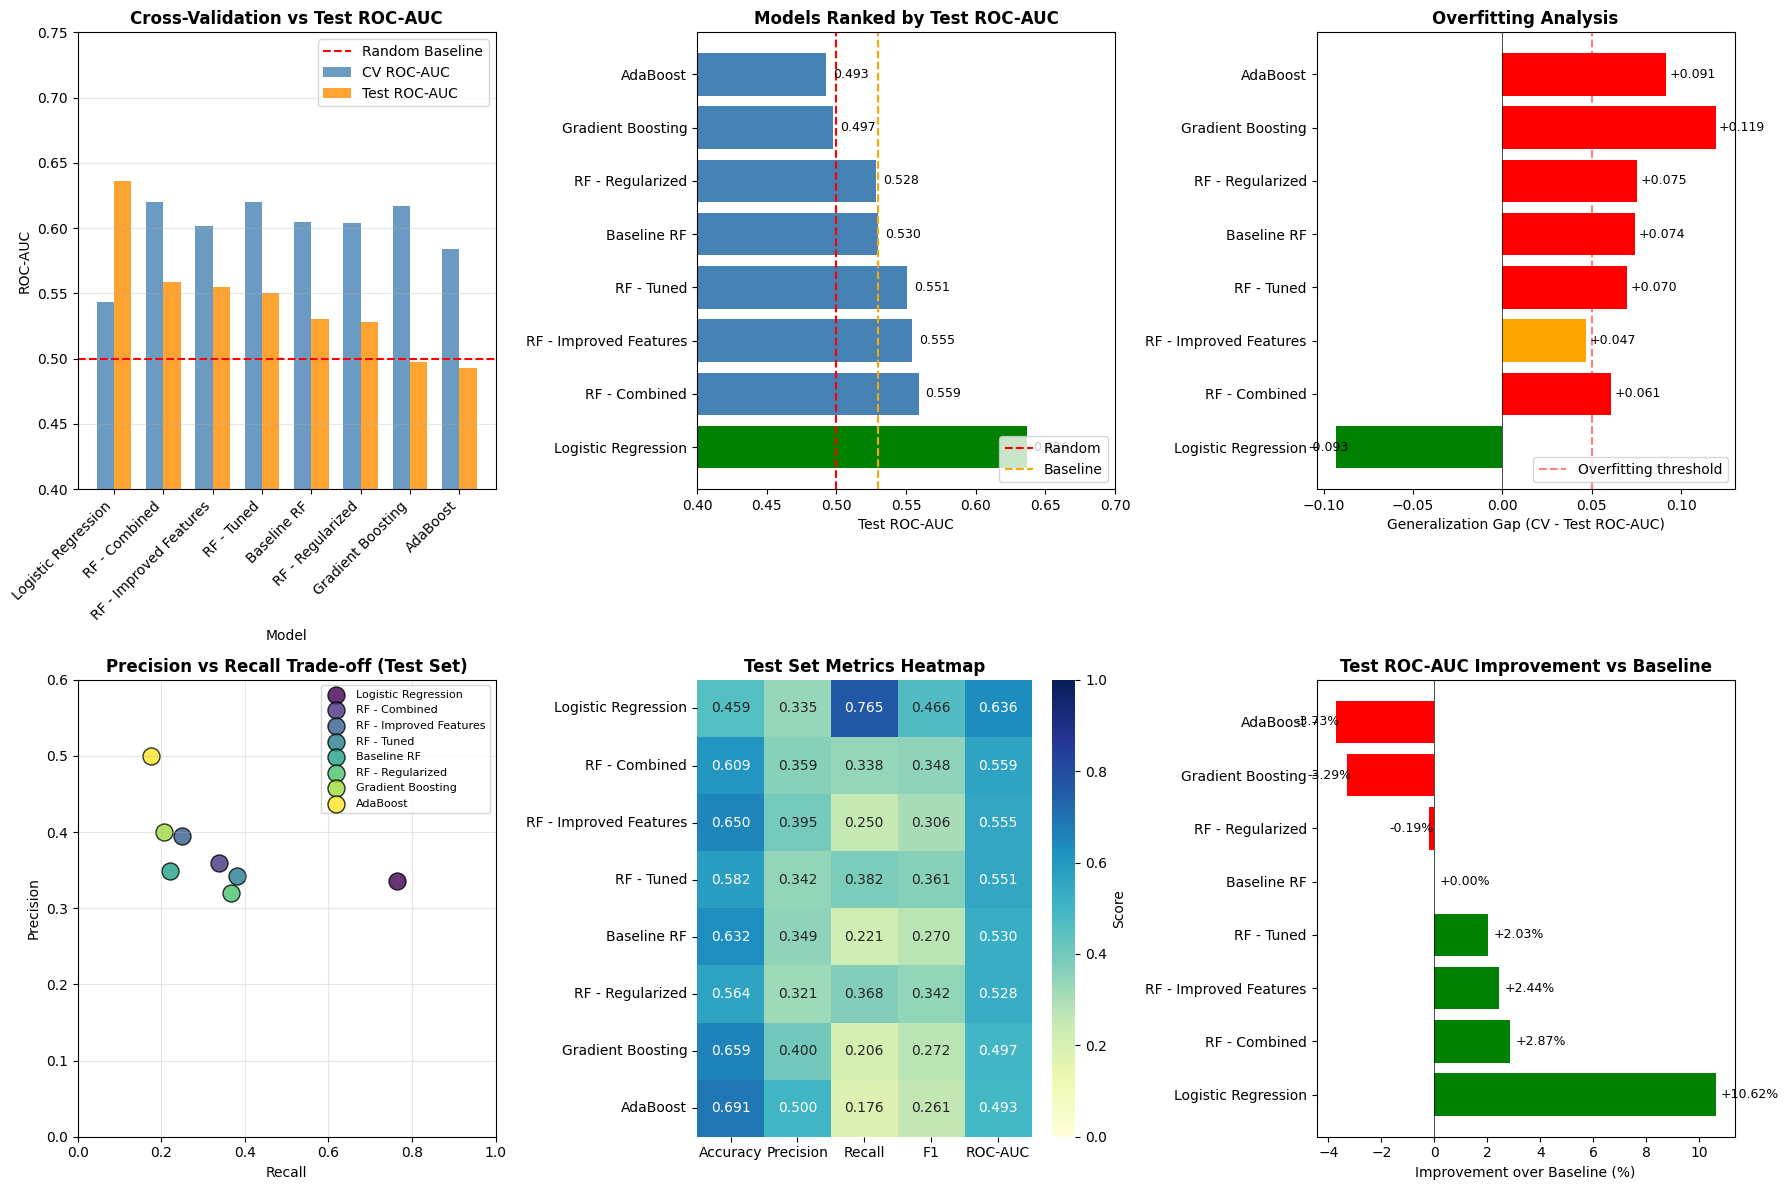

✓ Visualization saved to: data/ml/model_improvement_comparison.png

[Step 5] Saving results...
✓ Results saved to: data/ml/model_improvement_results.csv
✓ Best model (Logistic Regression) saved to: data/ml/best_model_improved.joblib

MODEL IMPROVEMENT EXPERIMENTS - FINAL SUMMARY

📋 EXPERIMENTAL METHODOLOGY:
  ✓ All models evaluated with 3-Fold TimeSeriesSplit Cross-Validation
  ✓ All models evaluated on the same held-out test set
  ✓ Same metrics computed for all models
  ✓ Generalization gap calculated to detect overfitting

📊 EXPERIMENTS CONDUCTED:
  0. Baseline Random Forest (original configuration)
  1. Improved Features (removed absolute features)
  2. Hyperparameter Tuning (GridSearchCV)
  3. Algorithm Comparison (Logistic Regression, Gradient Boosting, AdaBoost)
  4. Regularized Random Forest (reduced complexity)
  5. Combined Approach (improved features + moderate regularization)

📈 KEY RESULTS:
  Baseline CV ROC-AUC:     0.6046
  Baseline Test ROC-AUC:   0.5302
  Best Model:  

In [2]:
print("="*70)
print("FYP MODEL IMPROVEMENT EXPERIMENTS (CORRECTED)")
print("All experiments use identical evaluation conditions")
print("="*70)

# ============================================
# STEP 1: LOAD DATA AND SETUP
# ============================================

print("\n[Step 1] Loading data and setting up evaluation framework...")

# Load data from Task 12-14
train_df = pd.read_csv('data/ml/train_data.csv', parse_dates=['Snapshot_Date'])
val_df = pd.read_csv('data/ml/val_data.csv', parse_dates=['Snapshot_Date'])
test_df = pd.read_csv('data/ml/test_data.csv', parse_dates=['Snapshot_Date'])
feature_cols = pd.read_csv('data/ml/feature_columns.csv')['Feature'].tolist()

# Sort training data chronologically
train_df_sorted = train_df.sort_values('Snapshot_Date').reset_index(drop=True)

# Prepare X and y
X_train = train_df_sorted[feature_cols].copy()
y_train = train_df_sorted['Label'].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df['Label'].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df['Label'].copy()

# Fill missing values
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Create TimeSeriesSplit (same as Task 13)
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f"✓ Data loaded:")
print(f"  Training: {X_train.shape}")
print(f"  Validation: {X_val.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {len(feature_cols)}")
print(f"  Cross-validation: {N_SPLITS}-Fold TimeSeriesSplit")

# ============================================
# STEP 2: DEFINE STANDARDIZED EVALUATION FUNCTION
# ============================================

print("\n[Step 2] Defining standardized evaluation function...")

def evaluate_model(model, X_train, y_train, X_test, y_test, tscv, model_name):
    """
    Evaluate a model using both cross-validation and test set.
    Ensures all models are evaluated under identical conditions.
    
    Returns:
        dict: Dictionary containing all metrics
    """
    results = {'Model': model_name}
    
    # ===== CROSS-VALIDATION =====
    # Get CV scores for multiple metrics
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=tscv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_train, y_train, cv=tscv, scoring='precision')
    cv_recall = cross_val_score(model, X_train, y_train, cv=tscv, scoring='recall')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=tscv, scoring='f1')
    cv_roc_auc = cross_val_score(model, X_train, y_train, cv=tscv, scoring='roc_auc')
    
    # Store CV results
    results['CV_Accuracy_Mean'] = cv_accuracy.mean()
    results['CV_Accuracy_Std'] = cv_accuracy.std()
    results['CV_Precision_Mean'] = cv_precision.mean()
    results['CV_Precision_Std'] = cv_precision.std()
    results['CV_Recall_Mean'] = cv_recall.mean()
    results['CV_Recall_Std'] = cv_recall.std()
    results['CV_F1_Mean'] = cv_f1.mean()
    results['CV_F1_Std'] = cv_f1.std()
    results['CV_ROC_AUC_Mean'] = cv_roc_auc.mean()
    results['CV_ROC_AUC_Std'] = cv_roc_auc.std()
    
    # ===== TRAIN ON FULL TRAINING SET =====
    model.fit(X_train, y_train)
    
    # ===== TEST SET EVALUATION =====
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    results['Test_Accuracy'] = accuracy_score(y_test, y_test_pred)
    results['Test_Precision'] = precision_score(y_test, y_test_pred, zero_division=0)
    results['Test_Recall'] = recall_score(y_test, y_test_pred, zero_division=0)
    results['Test_F1'] = f1_score(y_test, y_test_pred, zero_division=0)
    results['Test_ROC_AUC'] = roc_auc_score(y_test, y_test_proba)
    
    # ===== GENERALIZATION GAP =====
    # Difference between CV and Test performance (indicates overfitting)
    results['Generalization_Gap'] = results['CV_ROC_AUC_Mean'] - results['Test_ROC_AUC']
    
    return results, model

def print_evaluation_results(results):
    """Print formatted evaluation results."""
    print(f"\n  Cross-Validation Results ({N_SPLITS}-Fold TimeSeriesSplit):")
    print(f"    Accuracy:  {results['CV_Accuracy_Mean']:.4f} ± {results['CV_Accuracy_Std']:.4f}")
    print(f"    Precision: {results['CV_Precision_Mean']:.4f} ± {results['CV_Precision_Std']:.4f}")
    print(f"    Recall:    {results['CV_Recall_Mean']:.4f} ± {results['CV_Recall_Std']:.4f}")
    print(f"    F1 Score:  {results['CV_F1_Mean']:.4f} ± {results['CV_F1_Std']:.4f}")
    print(f"    ROC-AUC:   {results['CV_ROC_AUC_Mean']:.4f} ± {results['CV_ROC_AUC_Std']:.4f}")
    
    print(f"\n  Test Set Results:")
    print(f"    Accuracy:  {results['Test_Accuracy']:.4f}")
    print(f"    Precision: {results['Test_Precision']:.4f}")
    print(f"    Recall:    {results['Test_Recall']:.4f}")
    print(f"    F1 Score:  {results['Test_F1']:.4f}")
    print(f"    ROC-AUC:   {results['Test_ROC_AUC']:.4f}")
    
    print(f"\n  Generalization Gap (CV - Test ROC-AUC): {results['Generalization_Gap']:.4f}")
    if results['Generalization_Gap'] > 0.05:
        print("    ⚠️ Warning: Significant overfitting detected")
    else:
        print("    ✓ Good generalization")

print("✓ Standardized evaluation function defined")

# Store all results
all_results = []

# ============================================
# EXPERIMENT 0: BASELINE RANDOM FOREST
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 0: BASELINE RANDOM FOREST")
print("="*70)

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nModel Configuration:")
print(f"  n_estimators: 100")
print(f"  max_depth: 10")
print(f"  min_samples_leaf: 5")
print(f"  class_weight: balanced")

baseline_results, baseline_model_trained = evaluate_model(
    baseline_rf, X_train, y_train, X_test, y_test, tscv, 'Baseline RF'
)
all_results.append(baseline_results)
print_evaluation_results(baseline_results)

# Store baseline ROC-AUC for comparison
baseline_cv_roc = baseline_results['CV_ROC_AUC_Mean']
baseline_test_roc = baseline_results['Test_ROC_AUC']

# ============================================
# EXPERIMENT 1: IMPROVED FEATURES
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 1: IMPROVED FEATURES")
print("="*70)

# Identify and remove problematic absolute features
absolute_features = ['Price', 'SMA_50', 'SMA_200', 'Avg_Volume_3M', 'Market_Cap']
existing_absolute = [f for f in absolute_features if f in feature_cols]

print(f"\nRemoving absolute features that may cause overfitting:")
print(f"  {existing_absolute}")

# Create improved feature set
improved_features = [f for f in feature_cols if f not in absolute_features]

print(f"\nOriginal features: {len(feature_cols)}")
print(f"Improved features: {len(improved_features)}")

# Prepare improved data
X_train_improved = X_train[improved_features].copy()
X_test_improved = X_test[improved_features].copy()

# Same model configuration as baseline
rf_improved_feat = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

improved_feat_results, rf_improved_feat_trained = evaluate_model(
    rf_improved_feat, X_train_improved, y_train, X_test_improved, y_test, tscv, 'RF - Improved Features'
)
all_results.append(improved_feat_results)
print_evaluation_results(improved_feat_results)

print(f"\n  Comparison to Baseline:")
print(f"    CV ROC-AUC:   {improved_feat_results['CV_ROC_AUC_Mean']:.4f} vs {baseline_cv_roc:.4f} ({(improved_feat_results['CV_ROC_AUC_Mean'] - baseline_cv_roc)*100:+.2f}%)")
print(f"    Test ROC-AUC: {improved_feat_results['Test_ROC_AUC']:.4f} vs {baseline_test_roc:.4f} ({(improved_feat_results['Test_ROC_AUC'] - baseline_test_roc)*100:+.2f}%)")

# ============================================
# EXPERIMENT 2: HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 2: HYPERPARAMETER TUNING (GridSearchCV)")
print("="*70)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 7, 10],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

print(f"\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Base model
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Grid search with TimeSeriesSplit
print("\nRunning GridSearchCV with TimeSeriesSplit (this may take a few minutes)...")
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate best model using our standardized function
best_rf_params = grid_search.best_params_
rf_tuned = RandomForestClassifier(
    **best_rf_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

tuned_results, rf_tuned_trained = evaluate_model(
    rf_tuned, X_train, y_train, X_test, y_test, tscv, 'RF - Tuned'
)
all_results.append(tuned_results)
print_evaluation_results(tuned_results)

print(f"\n  Comparison to Baseline:")
print(f"    CV ROC-AUC:   {tuned_results['CV_ROC_AUC_Mean']:.4f} vs {baseline_cv_roc:.4f} ({(tuned_results['CV_ROC_AUC_Mean'] - baseline_cv_roc)*100:+.2f}%)")
print(f"    Test ROC-AUC: {tuned_results['Test_ROC_AUC']:.4f} vs {baseline_test_roc:.4f} ({(tuned_results['Test_ROC_AUC'] - baseline_test_roc)*100:+.2f}%)")

# ============================================
# EXPERIMENT 3: ALGORITHM COMPARISON
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 3: ALGORITHM COMPARISON")
print("="*70)

print("\nComparing different ML algorithms under identical conditions...")

# Define models to compare
comparison_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    )
}

for model_name, model in comparison_models.items():
    print(f"\n--- {model_name} ---")
    
    model_results, trained_model = evaluate_model(
        model, X_train, y_train, X_test, y_test, tscv, model_name
    )
    all_results.append(model_results)
    print_evaluation_results(model_results)
    
    print(f"\n  Comparison to Baseline:")
    print(f"    CV ROC-AUC:   {model_results['CV_ROC_AUC_Mean']:.4f} vs {baseline_cv_roc:.4f} ({(model_results['CV_ROC_AUC_Mean'] - baseline_cv_roc)*100:+.2f}%)")
    print(f"    Test ROC-AUC: {model_results['Test_ROC_AUC']:.4f} vs {baseline_test_roc:.4f} ({(model_results['Test_ROC_AUC'] - baseline_test_roc)*100:+.2f}%)")
    
    # Store trained model for potential later use
    comparison_models[model_name] = trained_model

# ============================================
# EXPERIMENT 4: REGULARIZED RANDOM FOREST
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 4: REGULARIZED RANDOM FOREST")
print("="*70)

rf_regularized = RandomForestClassifier(
    n_estimators=50,           # Fewer trees
    max_depth=5,               # Shallower (was 10)
    min_samples_leaf=20,       # More samples per leaf (was 5)
    min_samples_split=30,      # More samples to split
    max_features=0.3,          # Only 30% of features per tree
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nRegularization settings (vs Baseline):")
print("  n_estimators:     50  (was 100)")
print("  max_depth:        5   (was 10)")
print("  min_samples_leaf: 20  (was 5)")
print("  min_samples_split: 30 (new)")
print("  max_features:     0.3 (new)")

regularized_results, rf_regularized_trained = evaluate_model(
    rf_regularized, X_train, y_train, X_test, y_test, tscv, 'RF - Regularized'
)
all_results.append(regularized_results)
print_evaluation_results(regularized_results)

print(f"\n  Comparison to Baseline:")
print(f"    CV ROC-AUC:   {regularized_results['CV_ROC_AUC_Mean']:.4f} vs {baseline_cv_roc:.4f} ({(regularized_results['CV_ROC_AUC_Mean'] - baseline_cv_roc)*100:+.2f}%)")
print(f"    Test ROC-AUC: {regularized_results['Test_ROC_AUC']:.4f} vs {baseline_test_roc:.4f} ({(regularized_results['Test_ROC_AUC'] - baseline_test_roc)*100:+.2f}%)")

# ============================================
# EXPERIMENT 5: COMBINED IMPROVEMENTS
# ============================================

print("\n" + "="*70)
print("EXPERIMENT 5: COMBINED IMPROVEMENTS")
print("="*70)

print("\nCombining: Improved Features + Moderate Regularization")

rf_combined = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,               # Moderate depth
    min_samples_leaf=10,       # Moderate regularization
    min_samples_split=15,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nCombined model settings:")
print("  Features:         Improved (removed absolute features)")
print("  n_estimators:     100")
print("  max_depth:        7   (moderate)")
print("  min_samples_leaf: 10  (moderate)")
print("  min_samples_split: 15")
print("  max_features:     sqrt")

combined_results, rf_combined_trained = evaluate_model(
    rf_combined, X_train_improved, y_train, X_test_improved, y_test, tscv, 'RF - Combined'
)
all_results.append(combined_results)
print_evaluation_results(combined_results)

print(f"\n  Comparison to Baseline:")
print(f"    CV ROC-AUC:   {combined_results['CV_ROC_AUC_Mean']:.4f} vs {baseline_cv_roc:.4f} ({(combined_results['CV_ROC_AUC_Mean'] - baseline_cv_roc)*100:+.2f}%)")
print(f"    Test ROC-AUC: {combined_results['Test_ROC_AUC']:.4f} vs {baseline_test_roc:.4f} ({(combined_results['Test_ROC_AUC'] - baseline_test_roc)*100:+.2f}%)")

# ============================================
# STEP 3: COMPREHENSIVE RESULTS COMPARISON
# ============================================

print("\n" + "="*70)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*70)

# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Calculate improvement over baseline
results_df['CV_vs_Baseline'] = ((results_df['CV_ROC_AUC_Mean'] - baseline_cv_roc) * 100).apply(lambda x: f"{x:+.2f}%")
results_df['Test_vs_Baseline'] = ((results_df['Test_ROC_AUC'] - baseline_test_roc) * 100).apply(lambda x: f"{x:+.2f}%")

# Sort by Test ROC-AUC
results_df_sorted = results_df.sort_values('Test_ROC_AUC', ascending=False).reset_index(drop=True)
results_df_sorted['Rank'] = range(1, len(results_df_sorted) + 1)

# ===== TABLE 1: CROSS-VALIDATION RESULTS =====
print("\n" + "="*70)
print("TABLE 1: CROSS-VALIDATION RESULTS (3-Fold TimeSeriesSplit)")
print("="*70)

cv_cols = ['Rank', 'Model', 'CV_Accuracy_Mean', 'CV_Precision_Mean', 'CV_Recall_Mean', 'CV_F1_Mean', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std']
cv_display = results_df_sorted[cv_cols].copy()
cv_display.columns = ['Rank', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Std']

# Format numbers
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Std']:
    cv_display[col] = cv_display[col].apply(lambda x: f"{x:.4f}")

print(cv_display.to_string(index=False))

# ===== TABLE 2: TEST SET RESULTS =====
print("\n" + "="*70)
print("TABLE 2: TEST SET RESULTS")
print("="*70)

test_cols = ['Rank', 'Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC', 'Test_vs_Baseline']
test_display = results_df_sorted[test_cols].copy()
test_display.columns = ['Rank', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'vs Baseline']

# Format numbers
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    test_display[col] = test_display[col].apply(lambda x: f"{x:.4f}")

print(test_display.to_string(index=False))

# ===== TABLE 3: GENERALIZATION ANALYSIS =====
print("\n" + "="*70)
print("TABLE 3: GENERALIZATION ANALYSIS (Overfitting Detection)")
print("="*70)

gen_cols = ['Rank', 'Model', 'CV_ROC_AUC_Mean', 'Test_ROC_AUC', 'Generalization_Gap']
gen_display = results_df_sorted[gen_cols].copy()
gen_display.columns = ['Rank', 'Model', 'CV ROC-AUC', 'Test ROC-AUC', 'Gap (CV - Test)']

# Format numbers
gen_display['CV ROC-AUC'] = gen_display['CV ROC-AUC'].apply(lambda x: f"{x:.4f}")
gen_display['Test ROC-AUC'] = gen_display['Test ROC-AUC'].apply(lambda x: f"{x:.4f}")
gen_display['Gap (CV - Test)'] = gen_display['Gap (CV - Test)'].apply(lambda x: f"{x:+.4f}")

print(gen_display.to_string(index=False))

print("\nInterpretation:")
print("  - Positive gap: Model performs better on CV than test (overfitting)")
print("  - Negative gap: Model performs better on test than CV (good generalization)")
print("  - Gap > 0.05: Significant overfitting concern")

# ===== IDENTIFY BEST MODEL =====
best_model_idx = results_df_sorted['Test_ROC_AUC'].idxmax()
best_model_name = results_df_sorted.loc[best_model_idx, 'Model']
best_cv_roc = results_df_sorted.loc[best_model_idx, 'CV_ROC_AUC_Mean']
best_test_roc = results_df_sorted.loc[best_model_idx, 'Test_ROC_AUC']

print("\n" + "="*70)
print("🏆 BEST MODEL IDENTIFICATION")
print("="*70)
print(f"\n  Best Model:     {best_model_name}")
print(f"  CV ROC-AUC:     {best_cv_roc:.4f}")
print(f"  Test ROC-AUC:   {best_test_roc:.4f}")
print(f"  Improvement:    {(best_test_roc - baseline_test_roc)*100:+.2f}% over baseline")

# ============================================
# STEP 4: VISUALIZATION
# ============================================

print("\n[Step 4] Creating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: CV vs Test ROC-AUC Comparison
ax1 = axes[0, 0]
x = np.arange(len(results_df_sorted))
width = 0.35
bars1 = ax1.bar(x - width/2, results_df_sorted['CV_ROC_AUC_Mean'], width, label='CV ROC-AUC', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, results_df_sorted['Test_ROC_AUC'], width, label='Test ROC-AUC', color='darkorange', alpha=0.8)
ax1.axhline(y=0.5, color='red', linestyle='--', label='Random Baseline')
ax1.set_xlabel('Model')
ax1.set_ylabel('ROC-AUC')
ax1.set_title('Cross-Validation vs Test ROC-AUC', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df_sorted['Model'], rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0.4, 0.75)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Test ROC-AUC Ranking
ax2 = axes[0, 1]
colors = ['green' if m == best_model_name else 'steelblue' for m in results_df_sorted['Model']]
bars = ax2.barh(results_df_sorted['Model'], results_df_sorted['Test_ROC_AUC'], color=colors)
ax2.axvline(x=0.5, color='red', linestyle='--', label='Random')
ax2.axvline(x=baseline_test_roc, color='orange', linestyle='--', label='Baseline')
ax2.set_xlabel('Test ROC-AUC')
ax2.set_title('Models Ranked by Test ROC-AUC', fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim(0.4, 0.7)
for bar, val in zip(bars, results_df_sorted['Test_ROC_AUC']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

# Plot 3: Generalization Gap
ax3 = axes[0, 2]
gaps = results_df_sorted['Generalization_Gap']
colors = ['red' if g > 0.05 else 'orange' if g > 0 else 'green' for g in gaps]
bars = ax3.barh(results_df_sorted['Model'], gaps, color=colors)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Overfitting threshold')
ax3.set_xlabel('Generalization Gap (CV - Test ROC-AUC)')
ax3.set_title('Overfitting Analysis', fontweight='bold')
ax3.legend(loc='lower right')
for bar, val in zip(bars, gaps):
    ax3.text(val + 0.002 if val >= 0 else val - 0.015, bar.get_y() + bar.get_height()/2, 
             f'{val:+.3f}', va='center', fontsize=9)

# Plot 4: Precision vs Recall
ax4 = axes[1, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df_sorted)))
for i, (_, row) in enumerate(results_df_sorted.iterrows()):
    ax4.scatter(row['Test_Recall'], row['Test_Precision'], s=150, c=[colors[i]], 
                label=row['Model'], alpha=0.8, edgecolors='black')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision vs Recall Trade-off (Test Set)', fontweight='bold')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 0.6)

# Plot 5: All Metrics Heatmap
ax5 = axes[1, 1]
metrics_for_heatmap = results_df_sorted[['Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']].set_index('Model')
metrics_for_heatmap.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax5, 
            cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
ax5.set_title('Test Set Metrics Heatmap', fontweight='bold')
ax5.set_ylabel('')

# Plot 6: Improvement Over Baseline
ax6 = axes[1, 2]
improvements = (results_df_sorted['Test_ROC_AUC'] - baseline_test_roc) * 100
colors = ['green' if x > 0 else 'red' for x in improvements]
bars = ax6.barh(results_df_sorted['Model'], improvements, color=colors)
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax6.set_xlabel('Improvement over Baseline (%)')
ax6.set_title('Test ROC-AUC Improvement vs Baseline', fontweight='bold')
for bar, val in zip(bars, improvements):
    ax6.text(val + 0.2 if val >= 0 else val - 1.5, bar.get_y() + bar.get_height()/2, 
             f'{val:+.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/ml/model_improvement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: data/ml/model_improvement_comparison.png")

# ============================================
# STEP 5: SAVE RESULTS AND BEST MODEL
# ============================================

print("\n[Step 5] Saving results...")

# Save detailed results
results_df_sorted.to_csv('data/ml/model_improvement_results.csv', index=False)
print("✓ Results saved to: data/ml/model_improvement_results.csv")

# Save best model
if best_test_roc > baseline_test_roc:
    # Determine which model to save
    if best_model_name == 'Logistic Regression':
        best_model_obj = comparison_models['Logistic Regression']
        # Retrain to ensure it's fitted
        best_model_obj.fit(X_train, y_train)
        joblib.dump(best_model_obj, 'data/ml/best_model_improved.joblib')
        model_type = 'Logistic Regression'
    elif best_model_name == 'RF - Combined':
        joblib.dump(rf_combined_trained, 'data/ml/best_model_improved.joblib')
        pd.DataFrame({'Feature': improved_features}).to_csv('data/ml/feature_columns_improved.csv', index=False)
        model_type = 'Random Forest (Combined)'
    elif best_model_name == 'RF - Tuned':
        joblib.dump(rf_tuned_trained, 'data/ml/best_model_improved.joblib')
        model_type = 'Random Forest (Tuned)'
    elif best_model_name == 'Gradient Boosting':
        best_model_obj = comparison_models['Gradient Boosting']
        best_model_obj.fit(X_train, y_train)
        joblib.dump(best_model_obj, 'data/ml/best_model_improved.joblib')
        model_type = 'Gradient Boosting'
    elif best_model_name == 'RF - Regularized':
        joblib.dump(rf_regularized_trained, 'data/ml/best_model_improved.joblib')
        model_type = 'Random Forest (Regularized)'
    elif best_model_name == 'RF - Improved Features':
        joblib.dump(rf_improved_feat_trained, 'data/ml/best_model_improved.joblib')
        pd.DataFrame({'Feature': improved_features}).to_csv('data/ml/feature_columns_improved.csv', index=False)
        model_type = 'Random Forest (Improved Features)'
    else:
        model_type = 'Unknown'
    
    print(f"✓ Best model ({model_type}) saved to: data/ml/best_model_improved.joblib")
else:
    print("⚠ No improvement over baseline. Keeping original model.")

# ============================================
# STEP 6: FINAL SUMMARY
# ============================================

print("\n" + "="*70)
print("MODEL IMPROVEMENT EXPERIMENTS - FINAL SUMMARY")
print("="*70)

print("\n📋 EXPERIMENTAL METHODOLOGY:")
print("  ✓ All models evaluated with 3-Fold TimeSeriesSplit Cross-Validation")
print("  ✓ All models evaluated on the same held-out test set")
print("  ✓ Same metrics computed for all models")
print("  ✓ Generalization gap calculated to detect overfitting")

print("\n📊 EXPERIMENTS CONDUCTED:")
print("  0. Baseline Random Forest (original configuration)")
print("  1. Improved Features (removed absolute features)")
print("  2. Hyperparameter Tuning (GridSearchCV)")
print("  3. Algorithm Comparison (Logistic Regression, Gradient Boosting, AdaBoost)")
print("  4. Regularized Random Forest (reduced complexity)")
print("  5. Combined Approach (improved features + moderate regularization)")

print(f"\n📈 KEY RESULTS:")
print(f"  Baseline CV ROC-AUC:     {baseline_cv_roc:.4f}")
print(f"  Baseline Test ROC-AUC:   {baseline_test_roc:.4f}")
print(f"  Best Model:              {best_model_name}")
print(f"  Best CV ROC-AUC:         {best_cv_roc:.4f}")
print(f"  Best Test ROC-AUC:       {best_test_roc:.4f}")
print(f"  Improvement:             {(best_test_roc - baseline_test_roc)*100:+.2f}%")

print("\n📁 FILES SAVED:")
print("  - data/ml/model_improvement_results.csv (detailed results)")
print("  - data/ml/model_improvement_comparison.png (visualizations)")
if best_test_roc > baseline_test_roc:
    print("  - data/ml/best_model_improved.joblib (best model)")

print("\n" + "="*70)
print("All experiments completed under identical evaluation conditions")
print("="*70)